Cell 1 - Importing python modules and data for the code:

In [36]:
!pip install yfinance
import yfinance as yf #Yahoo finance, contains historical market data relevant for the project
import numpy as np #for numerical calculations
np.random.seed(42) #conventional startpoint-fix to generate same sequence of random numbers each time so outputs match write-up
import pandas as pd #for working with the tabular data downloaded from Yahoo finance
import matplotlib.pyplot as plt #for creating graphical data representation
from scipy.stats import norm #imports the normal distribution function needed for the Black-Scholes formula
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) #stops unnecessary yfinance warnings appearing before printed values


Cell 2 - Gathering and calculating information about a stock:

In [37]:
stockticker = input("Please enter the ticker of the stock for pricing: ")
stockdata = yf.download(stockticker, period = "2y", progress = False) #this downloads the market data for the stock daily from 2 years ago to today, progress = False stops unneeded print
prices = stockdata["Close"] #stockdata has mutliple columns, we just want the close price as close-to-close returns are standard and easier to work with

returns = prices.pct_change().dropna() #need dropna() as we can't calculate percentage change for the first close price as there isn't a previous one to work with in our 2 year case
daily_vol = returns.std() #daily volatility commonly measured with standard deviation, .std
annual_vol = daily_vol * np.sqrt(252) #252 trading days yearly, std scales with square root of time

print(f"Current price is: {prices.iloc[-1].item():.2f}") #.iloc[-1] selects the last close price (most recent) and .item() ensures we take it as a float
print(f"Annualised volatility is: {annual_vol.item():.2%}")


Please enter the ticker of the stock for pricing: AAPL
Current price is: 333.92
Annualised volatility is: 28.92%


Cell 3 - Various further calculations and inputs for upcoming formulas:

In [38]:
S = prices.iloc[-1].item()
strike_pct = float(input("Enter strike price % above spot price (without % symbol): "))
K = S * (1 + (strike_pct / 100))
t = 0.5 #maturity time in years, using 6 months here
r = (float(input("Enter current UK 1 year gilt yield % (without % symbol): "))) / 100
sigma = annual_vol.item()
n_sims = 200_000 #number of simulations


Enter strike price % above spot price (without % symbol): 5
Enter current UK 1 year gilt yield % (without % symbol): 4.15


Cell 4 - Black-Scholes and Monte Carlo estimations of the call price:

In [39]:
def black_scholes_call_p(S, K, t, r, sigma): #used standard notation for the Black-Scholes fromula
  d1 = ((np.log(S / K)) + (r + 0.5*(sigma**2))*t) / (sigma * np.sqrt(t))
  d2 = d1 - (sigma * np.sqrt(t))
  call_p = (S * norm.cdf(d1)) - (K * np.exp(-r * t) * norm.cdf(d2))
  #utilised the black-scholes model above
  return call_p

def monte_carlo_call_p(S, K, t, r, sigma, n_sims):
  z_nums = np.random.standard_normal(n_sims) #generates n_sims random shocks from a standard normal distribution
  m_stock_p = S * np.exp(((r - (0.5 * (sigma**2))) * t ) + (sigma * np.sqrt(t) * z_nums)) #GBM model for the stock price
  payoffs = np.maximum(m_stock_p - K, 0) #computes all payoffs for each simulated stock price
  call_p = np.exp(-r * t) * np.mean(payoffs) #average payoff which is the monte carlo estimate of the call price, discounted to today
  return call_p, m_stock_p

b_s_p = black_scholes_call_p(S, K, t, r, sigma)
m_c_p, price_sims = monte_carlo_call_p(S, K ,t, r, sigma, n_sims)
print(f"Black-Scholes Call Price: £{b_s_p:.2f}")
print(f"Monte Carlo Call Price: £{m_c_p:.2f}")

Black-Scholes Call Price: £23.09
Monte Carlo Call Price: £23.12


Cell 5 - Histogram of the stock price simulations compared with the strike price:

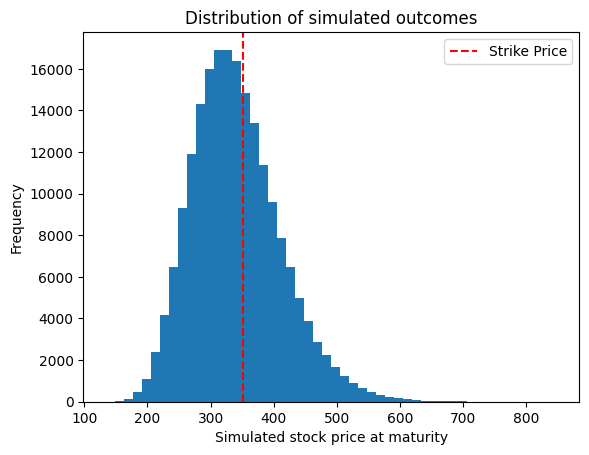

In [40]:
plt.hist(price_sims, bins = 50) #bins = 50 creates 50 bars on the histogram
plt.axvline(K, color = "red", linestyle = "--", label = "Strike Price")
plt.xlabel("Simulated stock price at maturity")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of simulated outcomes")
plt.savefig("price_distribution_plot.png", dpi = 150, bbox_inches = "tight") #saves graph at high resolution and with unnecessary blank borders
plt.show()


Cell 6 - Graphical representation of the Monte Carlo convergence to Black-Scholes:

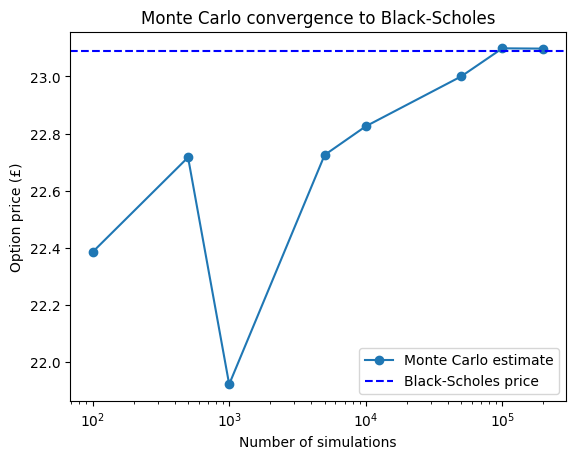

In [41]:
sim_counts = [100, 500, 1000, 5000, 10000, 50000, 100000, 200000] #to see how simulation count affects convergence to Black-Scholes
m_c_estimates = [monte_carlo_call_p(S, K, t, r, sigma, n)[0] for n in sim_counts]

plt.plot(sim_counts, m_c_estimates, marker = "o", label = "Monte Carlo estimate")
plt.axhline(b_s_p, color = "blue", linestyle = "--", label = "Black-Scholes price")
plt.xscale("log") #using a log scale for simulation number to show b-s convergence better visually
plt.xlabel("Number of simulations")
plt.ylabel("Option price (£)")
plt.legend()
plt.title("Monte Carlo convergence to Black-Scholes")
plt.savefig("m_c_convergence_plot.png", dpi = 150, bbox_inches = "tight")
plt.show()

Cell 7 - Delta calculation:

In [42]:
h = 0.01 #will use this below on the spot price to see how much the option price changes to a small nudge on the stock price
def black_scholes_delta(S, K, t, r, sigma, h):
  return (black_scholes_call_p(S+h, K, t, r, sigma) - black_scholes_call_p(S-h, K, t, r, sigma)) / (2 *h)

delta = black_scholes_delta(S, K, t, r, sigma, h)
print(f"Delta: {delta:.3f}")

Delta: 0.486
